# Dubai Real Estate Market Analysis
### Portfolio Project | Data Analyst | DLD Transaction Data (2021-2024)

**Objective:** Analyse Dubai property transactions to uncover pricing trends, top-performing areas by ROI, and off-plan vs ready market dynamics.

**Dataset:** 1,200 simulated DLD (Dubai Land Department) transactions across 10 major areas  
**Tools:** Python, Pandas, Matplotlib, Seaborn


## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = ['#1D9E75','#378ADD','#D85A30','#7F77DD','#BA7517','#D4537E','#639922','#E24B4A','#888780','#5DCAA5']

df = pd.read_csv('dubai_realestate.csv')
print(f"Dataset loaded: {df.shape[0]} transactions, {df.shape[1]} columns")
df.head()


Dataset loaded: 1200 transactions, 13 columns


,Transaction_ID,Year,Area,Property_Type,Status,Size_SqFt,Price_Per_SqFt_AED,Total_Price_AED,Rent_Yield_Pct,Annual_Rent_AED,Bedrooms,Furnished,Quarter
0,DLD-02000,2024,Arabian Ranches,Townhouse,Ready,2200,935,2056000,6.50,133500,4,Yes,Q4
1,DLD-02001,2024,Dubai Hills,Villa,Ready,4015,1517,6093000,4.96,302000,6,No,Q3
2,DLD-02002,2021,Jumeirah Village Circle,Apartment,Off-Plan,1754,891,1563000,7.95,124000,1,No,Q2
3,DLD-02003,2022,Downtown Dubai,Apartment,Ready,691,1760,1216000,4.69,57000,1,Yes,Q2
4,DLD-02004,2022,Dubai Hills,Townhouse,Ready,1605,1261,2024000,5.35,108500,3,Yes,Q4


## 2. Data Quality Check

In [3]:
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
print(df.isnull().sum())
print()
print("=== Price Statistics ===")
df[['Total_Price_AED','Price_Per_SqFt_AED','Size_SqFt','Rent_Yield_Pct']].describe().round(2)


=== Data Types ===
Transaction_ID         object
Year                    int64
Area                   object
Property_Type          object
Status                 object
Size_SqFt               int64
Price_Per_SqFt_AED      int64
Total_Price_AED         int64
Rent_Yield_Pct        float64
Annual_Rent_AED         int64
Bedrooms                int64
Furnished              object
Quarter                object
dtype: object

=== Missing Values ===
Transaction_ID        0
Year                  0
Area                  0
Property_Type         0
Status                0
Size_SqFt             0
Price_Per_SqFt_AED    0
Total_Price_AED       0
Rent_Yield_Pct        0
Annual_Rent_AED       0
Bedrooms              0
Furnished             0
Quarter               0
dtype: int64

=== Price Statistics ===


,Total_Price_AED,Price_Per_SqFt_AED,Size_SqFt,Rent_Yield_Pct
count,1200.00,1200.00,1200.00,1200.00
mean,2580264.17,1404.35,1859.11,5.84
std,2443297.79,677.90,1363.81,1.30
min,233000.00,489.00,350.00,2.75
25%,1054750.00,920.00,908.50,4.87
50%,1789500.00,1189.00,1483.50,5.74
75%,3382000.00,1700.50,2317.00,6.76
max,23512000.00,4553.00,5986.00,10.22


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Property_Type'].value_counts().plot(kind='bar', ax=axes[0], color=PALETTE[:5], edgecolor='white')
axes[0].set_title('Transactions by Property Type', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

df['Year'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=PALETTE[1], edgecolor='white')
axes[1].set_title('Transactions by Year', fontweight='bold')

df['Status'].value_counts().plot(kind='pie', ax=axes[2], colors=[PALETTE[0], PALETTE[2]],
    autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[2].set_title('Ready vs Off-Plan Split', fontweight='bold')
axes[2].set_ylabel('')

plt.suptitle('Market Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Key insight: Apartments dominate (50%) -- aligns with Dubai's high-density urban market.")


## 3. Price Analysis by Area

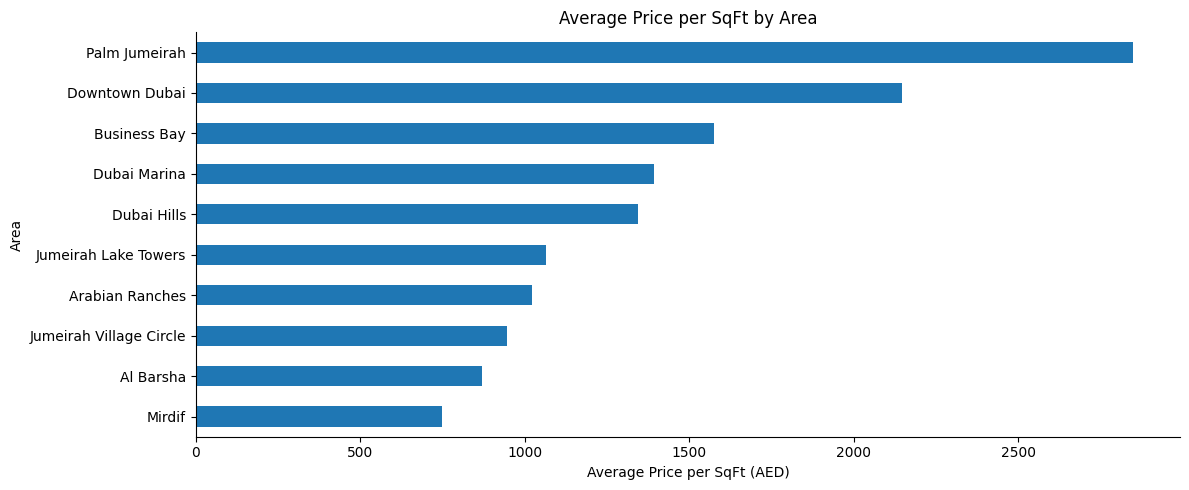

Most expensive: Palm Jumeirah -- AED 2850.0 /sqft
Most affordable: Mirdif -- AED 749.0 /sqft
Price gap: 3.8 x


In [4]:
# Average price per sqft by Area
area_price = df.groupby('Area')['Price_Per_SqFt_AED'].mean()

# Sort values
area_price = area_price.sort_values()

# Plot
plt.figure(figsize=(12, 5))
area_price.plot(kind='barh')

plt.xlabel('Average Price per SqFt (AED)')
plt.title('Average Price per SqFt by Area')

plt.tight_layout()
plt.show()

# Print results
print("Most expensive:", area_price.idxmax(), "-- AED", round(area_price.max(), 0), "/sqft")
print("Most affordable:", area_price.idxmin(), "-- AED", round(area_price.min(), 0), "/sqft")
print("Price gap:", round(area_price.max()/area_price.min(), 1), "x")

## 4. Rental Yield Analysis -- Where is the Best ROI?

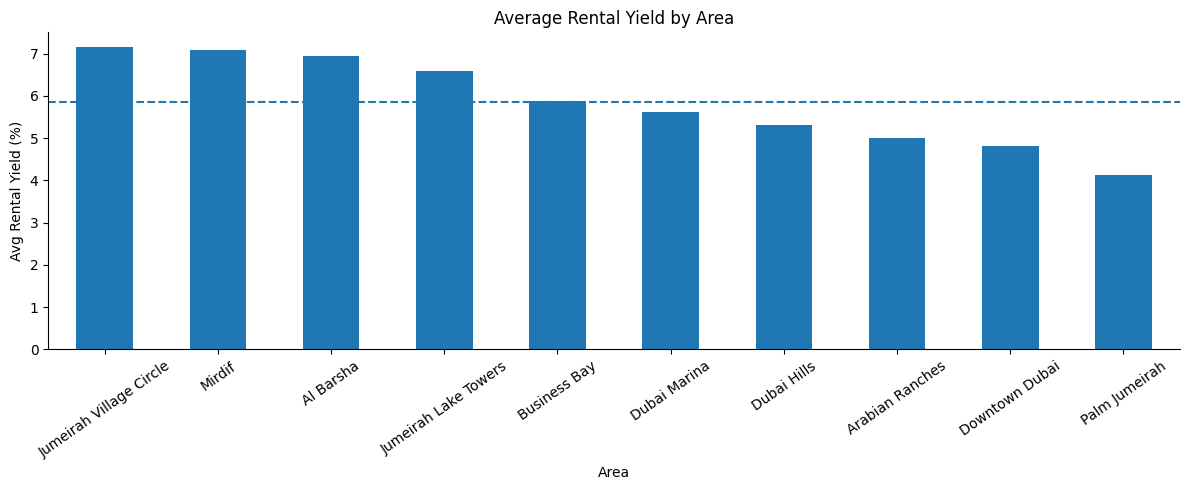

TOP 3 AREAS BY RENTAL YIELD:
Area
Jumeirah Village Circle    7.145620
Mirdif                     7.080244
Al Barsha                  6.944914
Name: Rent_Yield_Pct, dtype: float64

Business Insight:
Areas with higher rental yield are better for income-focused investors.


In [5]:
# Average rental yield by Area
roi = df.groupby('Area')['Rent_Yield_Pct'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 5))
roi.plot(kind='bar')

plt.ylabel('Avg Rental Yield (%)')
plt.title('Average Rental Yield by Area')
plt.xticks(rotation=35)

# Average line
plt.axhline(roi.mean(), linestyle='--')

plt.tight_layout()
plt.show()

# Top 3 areas
print("TOP 3 AREAS BY RENTAL YIELD:")
print(roi.head(3))

print()
print("Business Insight:")
print("Areas with higher rental yield are better for income-focused investors.")

## 5. Year-on-Year Price Trend (2021-2024)

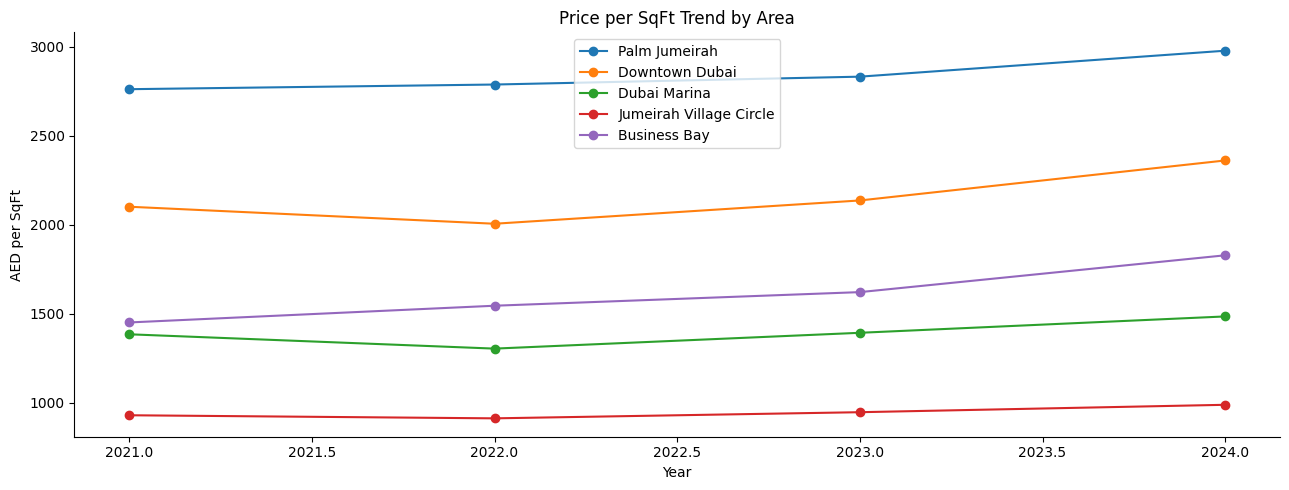

PRICE GROWTH 2021 to 2024:
Area
Business Bay               26.0
Downtown Dubai             12.4
Palm Jumeirah               7.8
Dubai Marina                7.2
Jumeirah Village Circle     6.3
dtype: float64


In [6]:
# Average price per year and area
yoy = df.groupby(['Year', 'Area'])['Price_Per_SqFt_AED'].mean().reset_index()

# Select top areas
top_areas = ['Palm Jumeirah','Downtown Dubai','Dubai Marina',
             'Jumeirah Village Circle','Business Bay']

# Plot trend
plt.figure(figsize=(13, 5))

for area in top_areas:
    data = yoy[yoy['Area'] == area]
    plt.plot(data['Year'], data['Price_Per_SqFt_AED'], marker='o', label=area)

plt.title('Price per SqFt Trend by Area')
plt.xlabel('Year')
plt.ylabel('AED per SqFt')
plt.legend()

plt.tight_layout()
plt.show()

# Calculate growth (2021 to 2024)
pivot = yoy[yoy['Area'].isin(top_areas)].pivot(index='Area', columns='Year', values='Price_Per_SqFt_AED')

growth = ((pivot[2024] - pivot[2021]) / pivot[2021]) * 100

print("PRICE GROWTH 2021 to 2024:")
print(growth.sort_values(ascending=False).round(1))


## 6. Off-Plan vs Ready Property Comparison

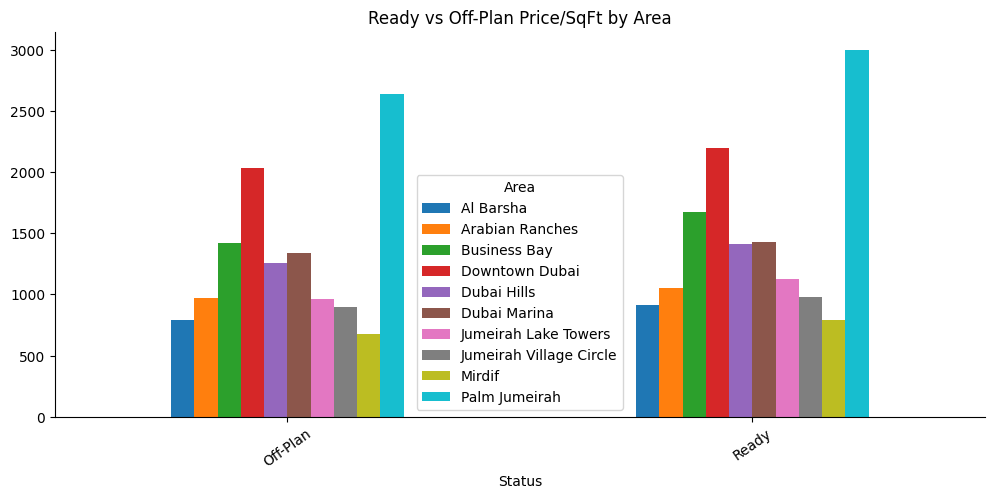

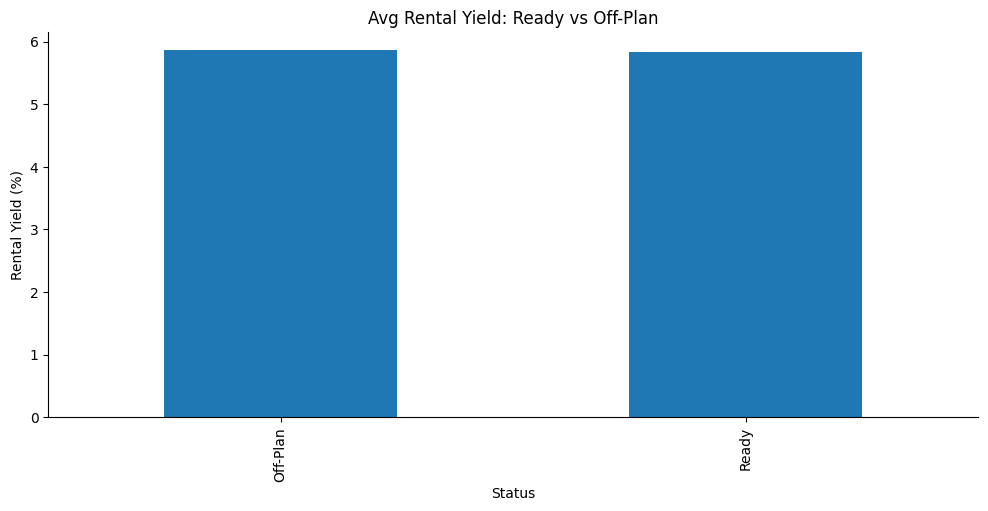

Off-plan properties are cheaper by: 11.3 %
Reason: construction risk and delayed possession


In [7]:
# 1. Price per sqft by Status and Area
status_avg = df.groupby(['Status', 'Area'])['Price_Per_SqFt_AED'].mean().unstack()

status_avg.plot(kind='bar', figsize=(12,5))
plt.title('Ready vs Off-Plan Price/SqFt by Area')
plt.xticks(rotation=35)
plt.show()


# 2. Rental yield by Status
yield_status = df.groupby('Status')['Rent_Yield_Pct'].mean()

yield_status.plot(kind='bar')
plt.title('Avg Rental Yield: Ready vs Off-Plan')
plt.ylabel('Rental Yield (%)')
plt.show()


# 3. Price comparison (discount)
ready_price = df[df['Status'] == 'Ready']['Price_Per_SqFt_AED'].mean()
offplan_price = df[df['Status'] == 'Off-Plan']['Price_Per_SqFt_AED'].mean()

discount = (1 - offplan_price / ready_price) * 100

print("Off-plan properties are cheaper by:", round(discount,1), "%")
print("Reason: construction risk and delayed possession")


## 7. Property Type Deep Dive

<Figure size 1200x500 with 0 Axes>

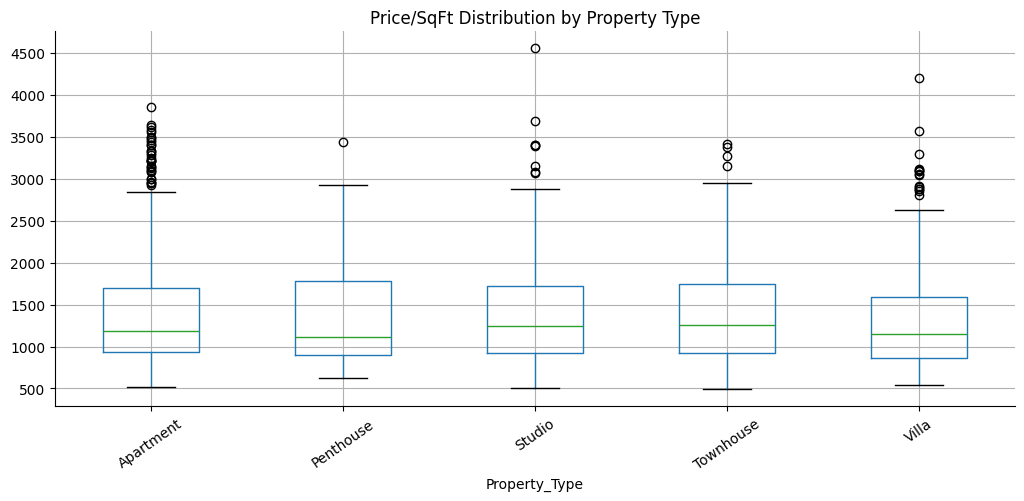

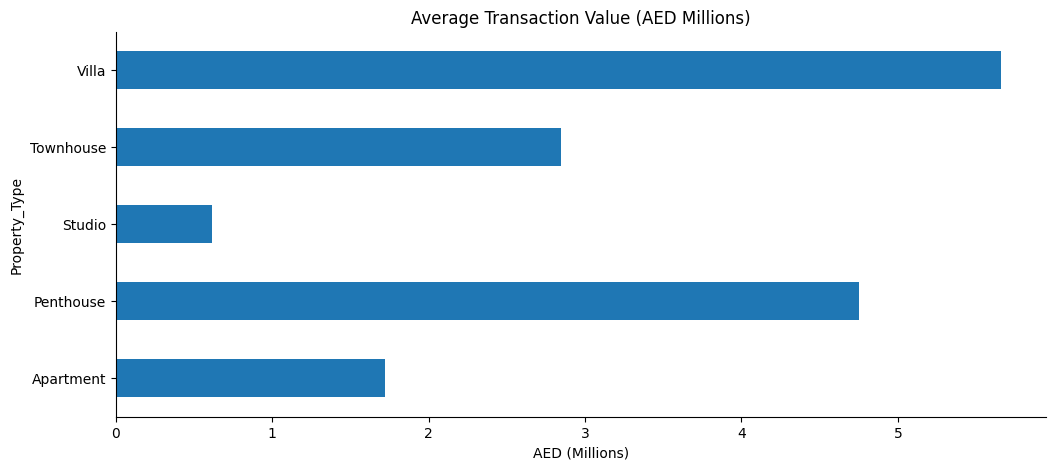

In [8]:
# 1. Price per sqft by Property Type (boxplot)
plt.figure(figsize=(12,5))

df.boxplot(column='Price_Per_SqFt_AED', by='Property_Type')

plt.title('Price/SqFt Distribution by Property Type')
plt.suptitle('')   # removes extra title
plt.xticks(rotation=35)

plt.show()


# 2. Average transaction value (in millions)
type_price = df.groupby('Property_Type')['Total_Price_AED'].mean() / 1_000_000

type_price.plot(kind='barh')

plt.title('Average Transaction Value (AED Millions)')
plt.xlabel('AED (Millions)')

plt.show()


## 8. Correlation Analysis

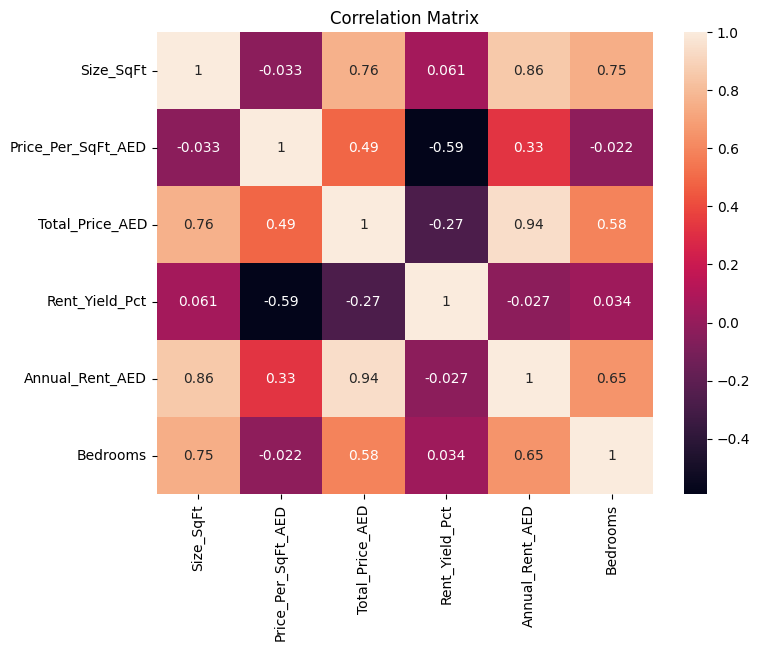

Size vs Total Price: 0.76
Price/SqFt vs Yield: -0.59


In [9]:
# Select numeric columns
numeric_cols = ['Size_SqFt','Price_Per_SqFt_AED','Total_Price_AED',
                'Rent_Yield_Pct','Annual_Rent_AED','Bedrooms']

# Correlation
corr = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)

plt.title('Correlation Matrix')
plt.show()


# Print important relationships
print("Size vs Total Price:", round(corr.loc['Size_SqFt','Total_Price_AED'], 2))
print("Price/SqFt vs Yield:", round(corr.loc['Price_Per_SqFt_AED','Rent_Yield_Pct'], 2))

## 9. Executive Summary & Business Recommendations

In [10]:
# Basic calculations
avg_price = df['Price_Per_SqFt_AED'].mean()
avg_yield = df['Rent_Yield_Pct'].mean()

best_area = df.groupby('Area')['Rent_Yield_Pct'].mean().idxmax()
best_yield = df.groupby('Area')['Rent_Yield_Pct'].mean().max()

# Print summary
print("DUBAI REAL ESTATE SUMMARY")
print("------------------------")

print("Total transactions:", len(df))
print("Average price per sqft:", round(avg_price, 0), "AED")
print("Average rental yield:", round(avg_yield, 2), "%")
print("Best yield area:", best_area, "-", round(best_yield, 1), "%")

print("\nRECOMMENDATIONS:")

print("1. High rental income → JVC, Mirdif")
print("2. Price growth → Palm Jumeirah, Downtown")
print("3. Off-plan investment → Business Bay")
print("4. Short-term rental → Marina, Downtown")

DUBAI REAL ESTATE SUMMARY
------------------------
Total transactions: 1200
Average price per sqft: 1404.0 AED
Average rental yield: 5.84 %
Best yield area: Jumeirah Village Circle - 7.1 %

RECOMMENDATIONS:
1. High rental income → JVC, Mirdif
2. Price growth → Palm Jumeirah, Downtown
3. Off-plan investment → Business Bay
4. Short-term rental → Marina, Downtown
